# Linear Regression Testing

## Calculating Coefficients Manually
b1 = ( Σxy - ΣxΣy / n ) / ( Σx² - (Σx)² / n )

b0 = ( Σy / n ) - b1 * ( Σx / n )

In [35]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

import constants as C

In [36]:
df = pd.read_csv(C.SUMMARY_DATA_PATH)
df

,YEAR,Total_Distracted_Fatalities,Mobile_Phone_Fatalities,Mobile_Phone_Proportion,Year_Index
0,2010,2986,684,0.229069,1
1,2011,2870,651,0.226829,2
2,2012,4579,629,0.137366,3
3,2013,4550,673,0.147912,4
4,2014,4529,583,0.128726,5
5,2015,5019,732,0.145846,6
6,2016,5290,978,0.184877,7
7,2017,4529,681,0.150364,8
8,2018,3866,531,0.137351,9
9,2019,4081,566,0.138691,10


In [63]:
x = df['Year_Index'].values
y = df['Mobile_Phone_Proportion'].values
n = len(x)

x_bar = np.mean(x)
y_bar = np.mean(y)

In [57]:
# Formula: Sum((x - x_bar)(y - y_bar)) / Sum((x - x_bar)^2)
numerator = np.sum((x - x_bar) * (y - y_bar))
denominator = np.sum((x - x_bar)**2)  # This is also SS_xx
numerator, denominator

(np.float64(-0.6233690531139655), np.float64(82.5))

In [60]:
b1 = numerator / denominator
b0 = y_bar - (b1 * x_bar)

print(f"Calculated coefficients:\n b0 (intercept): {b0}\n b1 (slope): {b1}")

print(f"\nRegression Equation: y = {b0:.4f} + {b1:.4f}x")

Calculated coefficients:
 b0 (intercept): 0.2042611934950834
 b1 (slope): -0.007555988522593521

Regression Equation: y = 0.2043 + -0.0076x


In [72]:
# Calculate predicted y values (y_hat) and SSE
y_pred = b0 + b1 * x

In [ ]:
# Calculate Sum of Squared Error (SSE)
# Formula: SSE = Σ(y - y_hat)^2
sse = np.sum((y - y_pred)**2)

# Calculate Standard Error of Estimate (S_yx)
# Formula: S_yx = sqrt(SSE / (n - 2))
s_yx = np.sqrt(sse / (n - 2))

# Calculate Standard Error of the Slope (S_b1)
# Formula: S_b1 = S_yx / sqrt(SS_xx)
s_b1 = s_yx / np.sqrt(denominator)

In [74]:
print("--- Linear Regression Test Results ---")
print(f"Slope (b1)                       : {b1:.5f}")
print(f"Intercept (b0)                   : {b0:.5f}")
print(f"Sum of Squared Error (SSE)       : {sse:.5f}")
print(f"Standard Error of Estimate (Syx) : {s_yx:.5f}")
print(f"Standard Error of Slope (Sb1)    : {s_b1:.5f}")

--- Linear Regression Test Results ---
Slope (b1)                       : -0.00756
Intercept (b0)                   : 0.20426
Sum of Squared Error (SSE)       : 0.00797
Standard Error of Estimate (Syx) : 0.03156
Standard Error of Slope (Sb1)    : 0.00347


In [76]:
# t-test
# Null Hypothesis: beta_1 = 0 (No linear relationship)
# Formula: t = (b1 - 0) / S_b1
t_stat = b1 / s_b1

# Calculate P-value (Two-tailed test with n-2 degrees of freedom)
df = n - 2
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"t-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject Null Hypothesis. There IS a significant linear relationship.")
else:
    print("\nResult: Fail to Reject Null Hypothesis. There is NO significant linear relationship.")

t-statistic : -2.1745
P-value     : 0.0614

Result: Fail to Reject Null Hypothesis. There is NO significant linear relationship.


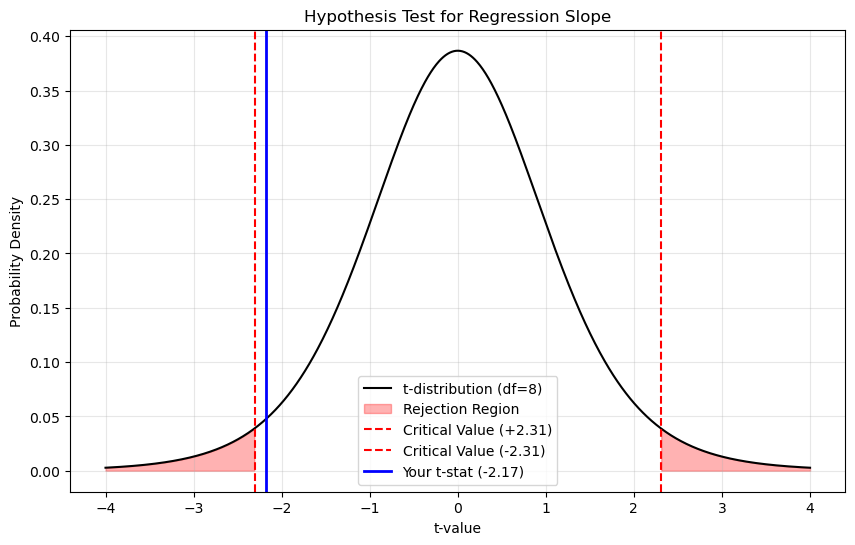

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- 1. Setup Data for Plotting ---
# (Assumes you have run the previous calculation code)
# Recalculating critical value just in case
alpha = 0.05
df = n - 2
t_critical = stats.t.ppf(1 - alpha/2, df)  # Two-tailed critical value

# Create a range of t-values for the x-axis
x_vals = np.linspace(-4, 4, 1000)
# Adjust range if your t-stat is very large (e.g., if t_stat is 10, widen the plot)
if abs(t_stat) > 3.5:
    x_vals = np.linspace(-(abs(t_stat)+1), abs(t_stat)+1, 1000)

y_vals = stats.t.pdf(x_vals, df)

# --- 2. Create the Plot ---
plt.figure(figsize=(10, 6))

# Plot the t-distribution curve
plt.plot(x_vals, y_vals, label=f't-distribution (df={df})', color='black')

# Shade the Rejection Regions (Tails)
plt.fill_between(x_vals, y_vals, where=(x_vals >= t_critical), color='red', alpha=0.3, label='Rejection Region')
plt.fill_between(x_vals, y_vals, where=(x_vals <= -t_critical), color='red', alpha=0.3)

# Add Critical Value Lines
plt.axvline(t_critical, color='red', linestyle='--', label=f'Critical Value (+{t_critical:.2f})')
plt.axvline(-t_critical, color='red', linestyle='--', label=f'Critical Value (-{t_critical:.2f})')

# Add YOUR Calculated t-statistic Line
plt.axvline(t_stat, color='blue', linewidth=2, label=f'Your t-stat ({t_stat:.2f})')

# --- 3. Formatting ---
plt.title('Hypothesis Test for Regression Slope')
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

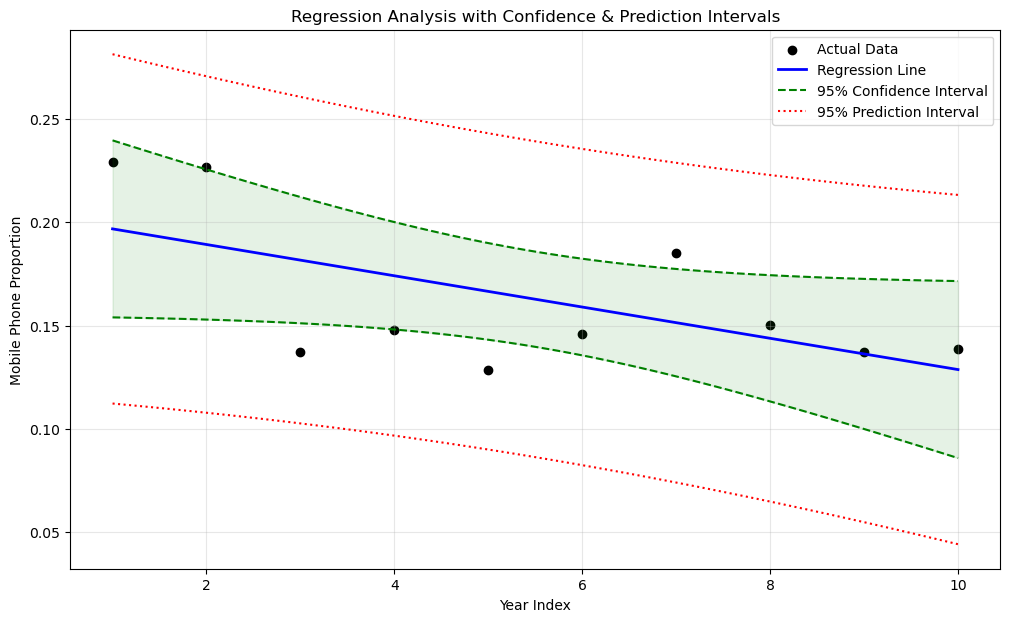

In [80]:
# --- 1. Generate Points for Smooth Lines ---
# Create a smooth range of X values spanning your data
x_plot = np.linspace(min(x), max(x), 100)

# Calculate predicted Y for these smooth X values
y_plot_pred = b0 + b1 * x_plot

# --- 2. Calculate Intervals Manually (Formulas from Ch 14) ---
# SS_xx (sum of squared deviations of x)
ss_xx = np.sum((x - x_bar)**2)

# Lists to store the bounds
ci_lower, ci_upper = [], []
pi_lower, pi_upper = [], []

for val in x_plot:
    # Term common to both formulas: sqrt( 1/n + (xp - mean)^2 / SSxx )
    # Note: For Prediction Interval, we add +1 inside the sqrt

    # Distance of this X from the mean X
    dist_metric = (val - x_bar)**2 / ss_xx

    # Standard Error for Confidence Interval
    se_ci = s_yx * np.sqrt(1/n + dist_metric)

    # Standard Error for Prediction Interval
    se_pi = s_yx * np.sqrt(1 + 1/n + dist_metric)

    # Calculate Bounds
    y_est = b0 + b1 * val
    ci_lower.append(y_est - t_critical * se_ci)
    ci_upper.append(y_est + t_critical * se_ci)
    pi_lower.append(y_est - t_critical * se_pi)
    pi_upper.append(y_est + t_critical * se_pi)

# --- 3. Create the Plot ---
plt.figure(figsize=(12, 7))

# 1. Scatter Plot of Actual Data
plt.scatter(x, y, color='black', label='Actual Data')

# 2. Regression Line
plt.plot(x_plot, y_plot_pred, color='blue',
         linewidth=2, label='Regression Line')

# 3. Confidence Interval Bands (Inner Lines)
plt.plot(x_plot, ci_lower, color='green',
         linestyle='--', label='95% Confidence Interval')
plt.plot(x_plot, ci_upper, color='green', linestyle='--')
plt.fill_between(x_plot, ci_lower, ci_upper, color='green', alpha=0.1)

# 4. Prediction Interval Bands (Outer Lines)
plt.plot(x_plot, pi_lower, color='red', linestyle=':',
         label='95% Prediction Interval')
plt.plot(x_plot, pi_upper, color='red', linestyle=':')

# --- Formatting ---
plt.title('Regression Analysis with Confidence & Prediction Intervals')
plt.xlabel('Year Index')
plt.ylabel('Mobile Phone Proportion')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()